<a href="https://colab.research.google.com/github/NymishaSalivendra/AI-ML-PROJECTS-AND-LABS/blob/main/AIML_Module_5_Lab_2_Loss_Functions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Regression Lab 2: Loss Functions


## Motivation

The main goal of machine learning tasks is to "learn" something about data we feed to our models. But how does the model actually learn anything? To understand this, we need to first understand what objective functions are.

Mathematically, objective functions are a function whose values we desire to minimize/maximize. In the context of machine learning, the objective is commonly referred to as a **loss function**. Loss functions indicate how well the model is doing on the dataset.

The value of the objective function is simply called **loss**. Our goal is to eventually find the best model parameters that has the least average loss on the data after training.


We are familiar with the idea of **error** from the linear regression lab. RMSE is a common loss function used in machine learning. However, there are many other loss functions employed, depending on what the task is (classification, regression etc.). In this lab, we will take a look at some common loss functions, and understand why they are used where they are.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')

# interactive visualization

# 1. Regression


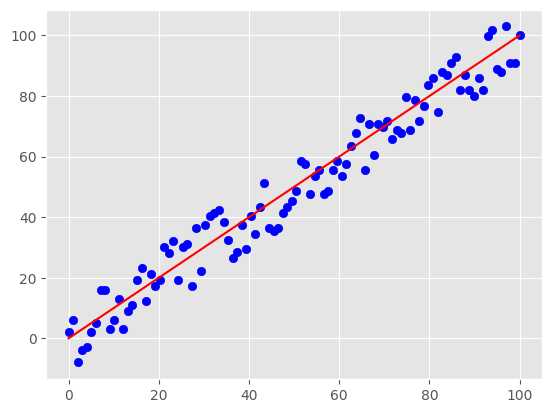

In [2]:
# initializing random data

np.random.seed(0)
x = np.linspace(0,100,100)
y_actual = np.copy(x)
y_pred = x + np.random.randint(-10,10,100)

plt.plot(x,y_actual,color="red")
plt.scatter(x,y_pred,color="blue")
plt.show()

### Mean Squared Error

As we have seen before, the formula for MSE is

$MSE = \frac{1}{m} \sum_{i=1}^n (y-y_p)^2$

The image below depicts a visualization of what the squared error is.

<img src="https://drive.google.com/uc?export=view&id=12jmqRrrqknIWKhwRpgRIJAErBjkEcyx9" width="350" height="350" align="middle"/>

MSE is also referred to as L2 loss.

Typically, we would want the units of error to be the same as the data, so we use Root Mean Squared Error instead.



In [3]:
mse = np.mean((y_actual-y_pred)**2)
print("MSE is: {}".format(mse))
print("RMSE is: {}".format(np.sqrt(mse)))

MSE is: 38.68
RMSE is: 6.219324722186485


### Mean Absolute Error

$MAE = \frac{1}{m} \sum_{i=1}^n |y-y_p|$

MAE is also commonly referred to as L1 loss.

In [4]:
mae = np.mean(np.abs(y_actual-y_pred))
print("MAE is: {}".format(mae))

MAE is: 5.5


MSE penalizes the model for making large errors by squaring the difference. However, this also means that MSE cannot handle outliers well, since they would throw the model off.

On the other hand, MAE is robust to outliers. But, MAE is non-differentiable, making it difficult to perform mathematical operations on it.

Hence, RMSE is most commonly used as a metric for evaluation.

# 2. Classification

Classification tasks involve some data, along with labels assigned to that data. For example, we may have pictures of cats and dogs, and the corresponding labels assigned to those images. We then want to train a model that can predict a label for some input image belonging to either label class (cat or dog).

## The concept of maximum likelihood

Ideally, we would want to obtain a model $\hat{\theta}$ which maximizes the probability of correctly predicting data. Mathematically, the likelihood is:

$ \prod_{i=1}^{N}  \: \hat{\theta_i}^{\theta_i}$

This is because our actual data ($\theta_i$) is either 0 or 1 depending on the label of the data, and our predicted data ($\hat{\theta_i}$) is a probability.

We usually consider the negative log of the likelihood, since log is monotonic and easier to deal with as an optimization problem.

Hence, we have

$MLE = $ arg min $\: - \sum_{i=1}^{N} \theta_i \: log \: \hat{\theta_i}$

\


## Entropy and Cross-Entropy

For some event $x$, we can obtain **information** based on its probability distribution. For example, for some event that occurs with $p=1$, we gain no information. Now, if we flip a coin and see that we obtained heads, we say that we got 1 bit of information.

Thus, the information $I$ of some event $x$ is:

$I = -log_2 \: p(x)$

We say that events with a low probability of occuring give high information, and those with a low probability give low information.

Now, if we have some random variable $X$, its **entropy** is the expected value of the information obtained.

$H(x) = - \sum_{k} p_k \: log \: p_k$

Now, suppose we are trying to correctly predict labels of some data. Let P be the true distribution of the labels, and Q be the predicted distribution of labels.

Cross-Entropy is then defined as:

$H(P,Q) = - \sum_{x} P(x)\: log \: Q(x)$

which is basically the entropy between two probability distributions over the same events.

\


## MLE and Cross-Entropy

So, in the case of classification, the equation for minimization of the cross-entropy between the actual data and the predicted data would be:

arg min $\: -\sum_{i=1}^{N} P(x) \: log \: Q(x)$

$= $ arg min $\: -\sum_{i=1}^{N} \theta_i \: log \: \hat{\theta_i}$


which is exactly the same as what we had obtained for minimizing the negative log likelihood. Hence, the two problems are equivalent.

1/1+e^(-x)

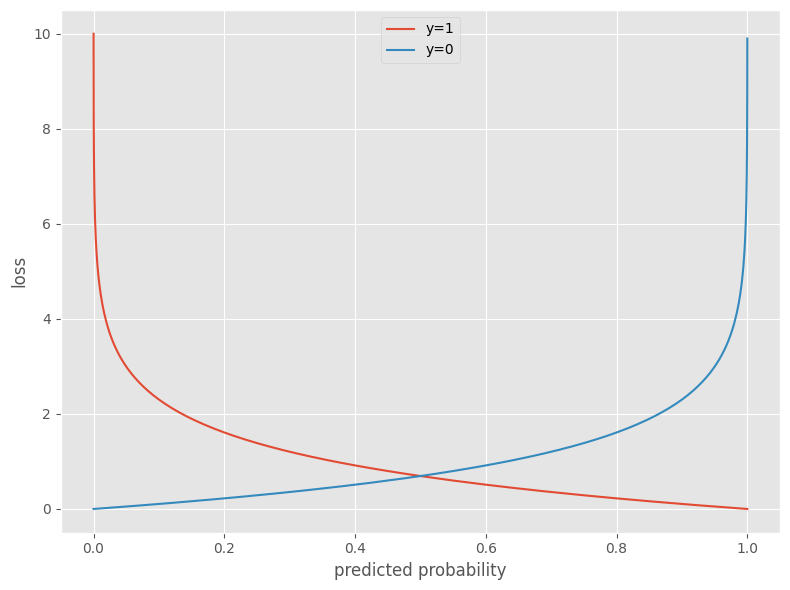

In [5]:
def sigmoid(z):
  return 1/(1 + np.exp(-z))

def cross_entropy_loss(y_,y):
  if y==1:
    return -np.log(y_)

  return -np.log(1-y_)

z = np.arange(-10, 10, 0.1)
h_z = sigmoid(z)

cost_1 = cross_entropy_loss(h_z, 1)
cost_0 = cross_entropy_loss(h_z, 0)

fig, ax = plt.subplots(figsize=(8,6))
plt.plot(h_z, cost_1, label='y=1')
plt.plot(h_z, cost_0, label='y=0')
plt.xlabel('predicted probability')
plt.ylabel('loss')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

## KNN-regression

Till now, we have studied KNN as a classification algorithm, which uses feature similarity and voting to decide the class labels of unseen data.

For regression, we use the same idea: We take the y-values of the k nearest neighbours, and compute their average, which is our predicted y-value. We do this for every x whose value we want to predict.

In the visualization below, we have k=3, and the red dots are the new x-values whose output we want to predict.

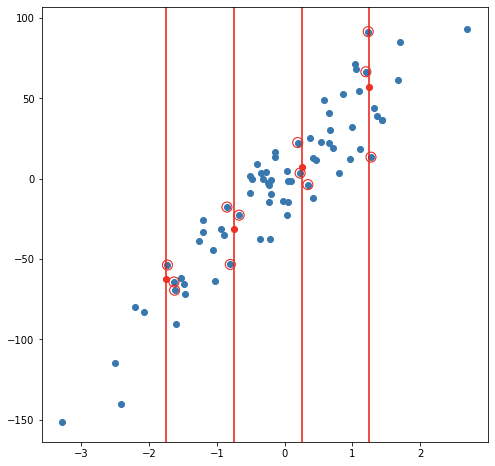

In [6]:
from sklearn import neighbors
from sklearn.metrics import mean_squared_error
from math import sqrt
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import numpy as np

In [7]:
train_path = "https://raw.githubusercontent.com/PranavTadimeti/Regression-lab2/main/BigMart-train.csv"

train = pd.read_csv(train_path)

In [8]:
# Preprocess Data

def preprocess(df):
  mean_weight = df['Item_Weight'].mean()
  df['Item_Weight'].fillna(mean_weight,inplace=True)

  mode_size = df['Outlet_Size'].mode()
  df['Outlet_Size'].fillna(mode_size,inplace=True)

  df.drop(['Item_Identifier','Outlet_Identifier'],axis=1,inplace=True)

  return pd.get_dummies(df)

train = preprocess(train)

train.head()

/tmp/ipykernel_24000/319556835.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Item_Weight'].fillna(mean_weight,inplace=True)
/tmp/ipykernel_24000/319556835.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales,Item_Fat_Content_LF,Item_Fat_Content_Low Fat,Item_Fat_Content_Regular,Item_Fat_Content_low fat,Item_Fat_Content_reg,...,Outlet_Size_High,Outlet_Size_Medium,Outlet_Size_Small,Outlet_Location_Type_Tier 1,Outlet_Location_Type_Tier 2,Outlet_Location_Type_Tier 3,Outlet_Type_Grocery Store,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3
0,9.30,0.016047,249.8092,1999,3735.1380,False,True,False,False,False,...,False,True,False,True,False,False,False,True,False,False
1,5.92,0.019278,48.2692,2009,443.4228,False,False,True,False,False,...,False,True,False,False,False,True,False,False,True,False
2,17.50,0.016760,141.6180,1999,2097.2700,False,True,False,False,False,...,False,True,False,True,False,False,False,True,False,False
3,19.20,0.000000,182.0950,1998,732.3800,False,False,True,False,False,...,False,False,False,False,False,True,True,False,False,False
4,8.93,0.000000,53.8614,1987,994.7052,False,True,False,False,False,...,True,False,False,False,False,True,False,True,False,False


In [9]:
train , test = train_test_split(train, test_size = 0.3)

x_train = train.drop('Item_Outlet_Sales', axis=1)
y_train = train['Item_Outlet_Sales']

x_test = test.drop('Item_Outlet_Sales', axis = 1)
y_test = test['Item_Outlet_Sales']

In [10]:
scaler = MinMaxScaler(feature_range=(0, 1))

x_train_scaled = scaler.fit_transform(x_train)
x_train = pd.DataFrame(x_train_scaled)

x_test_scaled = scaler.fit_transform(x_test)
x_test = pd.DataFrame(x_test_scaled)

In [11]:
def knn_regression(k,x_train,y_train,x_test,y_test):
    model = neighbors.KNeighborsRegressor(n_neighbors = k)

    model.fit(x_train, y_train)
    pred=model.predict(x_test)
    error = sqrt(mean_squared_error(y_test,pred))
    rmse_val.append(error)

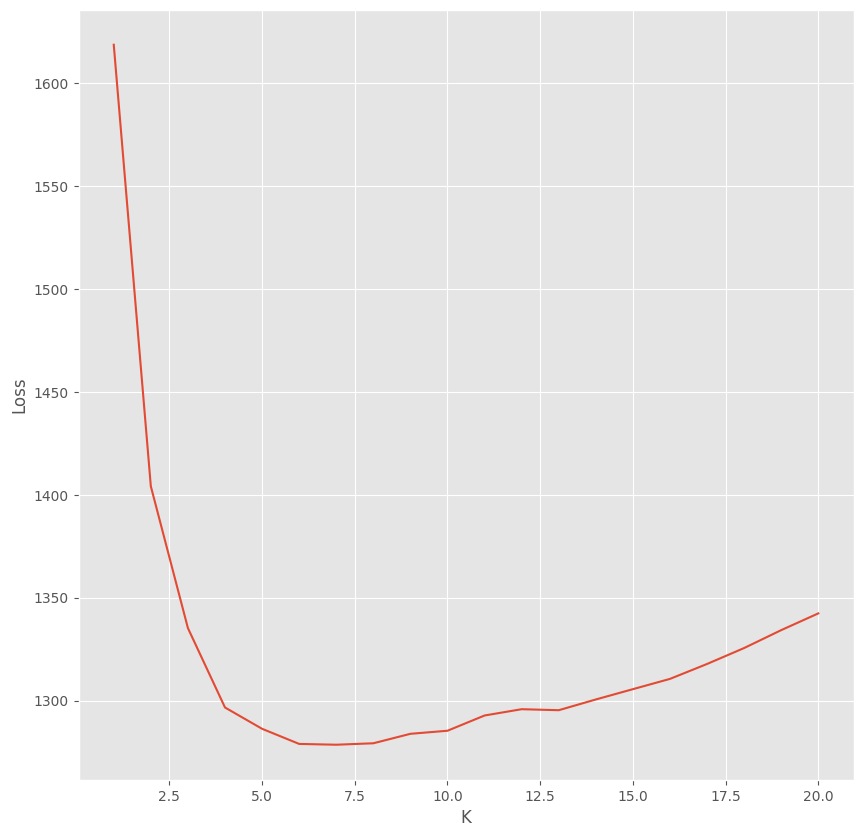

Minimum error 1278.5816281094171 is at k = 6


In [12]:
rmse_val = []

for k in range(1,21):
  knn_regression(k,x_train,y_train,x_test,y_test)

figure = plt.figure(figsize=(10,10))
plt.plot(np.arange(1,21),rmse_val)
plt.xlabel("K")
plt.ylabel("Loss")
plt.show()

rmse_val = np.asarray(rmse_val)
print("Minimum error {} is at k = {}".format(np.min(rmse_val),np.argmin(rmse_val)))

## Exercises

1. Try out these loss functions on regression tasks, and try to understand the model performance based on the loss function.
2. Explore other loss functions and try to understand when and why they are used.
3. Try out KNN-regression on other datasets see which values of K give the best results.
4. Try exploring what will happen if K is set to 1 or K is set to size of whole training dataset.

1. Comparing Loss Functions on Regression Tasks

Conceptual Summary

* Mean Squared Error (MSE / $L2$ Loss): Squares the errors ($e^2$). This heavily penalizes large errors or outliers. If your data has an anomaly, MSE will force the model to adjust significantly to accommodate it.
* Mean Absolute Error (MAE / $L1$ Loss): Takes the absolute difference ($|e|$). It treats all errors linearly, making it highly robust to outliers. However, its derivative is discontinuous at zero, making optimization slightly trickier.

In [13]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Generate synthetic data with a significant outlier
np.random.seed(42)
X = np.linspace(0, 10, 50).reshape(-1, 1)
y = 2 * X.squeeze() + 1 + np.random.normal(0, 1, 50)
y[45] = 40  # Massive outlier

# Fit a simple regression model
model = LinearRegression()
model.fit(X, y)
predictions = model.predict(X)

# Calculate and evaluate performance
mse = mean_squared_error(y, predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y, predictions)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f} (Same units as y)")
print(f"Mean Absolute Error (MAE): {mae:.4f}")

Mean Squared Error (MSE): 9.1783
Root Mean Squared Error (RMSE): 3.0296 (Same units as y)
Mean Absolute Error (MAE): 1.3112


2. . Exploring Other Advanced Loss Functions

Conceptual Summary
* Huber Loss: The best of both worlds. It acts like MSE when the error is small, but switches to MAE when the error is large (beyond a threshold $\delta$). This makes it differentiable everywhere while remaining robust to outliers.
* Log-Cosh Loss: Calculates the logarithm of the hyperbolic cosine of the error: $\log(\cosh(y - \hat{y}))$. Like Huber loss, it approximates $\frac{1}{2}x^2$ for small errors and $|x| - \log(2)$ for large ones, meaning it is smooth, twice-differentiable, and resilient to outliers.

<>:16: SyntaxWarning: invalid escape sequence '\d'
<>:18: SyntaxWarning: invalid escape sequence '\h'
<>:16: SyntaxWarning: invalid escape sequence '\d'
<>:18: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_24000/507105399.py:16: SyntaxWarning: invalid escape sequence '\d'
  plt.plot(errors, huber_loss(errors, delta=1.5), label="Huber Loss ($\delta=1.5$)", lw=2)
/tmp/ipykernel_24000/507105399.py:18: SyntaxWarning: invalid escape sequence '\h'
  plt.xlabel("Prediction Error ($y - \hat{y}$)")


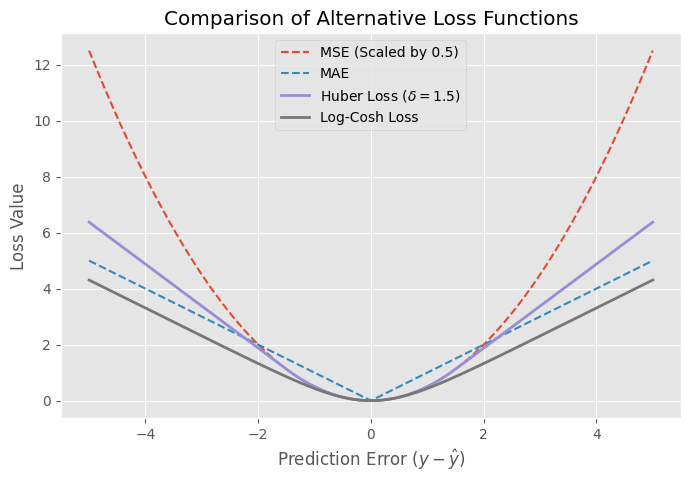

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Math representation of Huber and Log-Cosh
def huber_loss(error, delta=1.0):
    return np.where(np.abs(error) <= delta, 0.5 * (error**2), delta * (np.abs(error) - 0.5 * delta))

def logcosh_loss(error):
    return np.log(np.cosh(error))

errors = np.linspace(-5, 5, 500)

plt.figure(figsize=(8, 5))
plt.plot(errors, 0.5 * (errors**2), label="MSE (Scaled by 0.5)", linestyle="--")
plt.plot(errors, np.abs(errors), label="MAE", linestyle="--")
plt.plot(errors, huber_loss(errors, delta=1.5), label="Huber Loss ($\delta=1.5$)", lw=2)
plt.plot(errors, logcosh_loss(errors), label="Log-Cosh Loss", lw=2)
plt.xlabel("Prediction Error ($y - \hat{y}$)")
plt.ylabel("Loss Value")
plt.title("Comparison of Alternative Loss Functions")
plt.legend()
plt.grid(True)
plt.show()

3. Testing KNN-Regression on an Alternative Dataset

Conceptual Summary

To find the optimal hyperparameter $K$, we run a loop over a sequence of $K$ values using a standard benchmark dataset (like the California Housing dataset) and look for the point where the test RMSE is minimized.

The optimal value is K = 7 with an RMSE of 0.4119


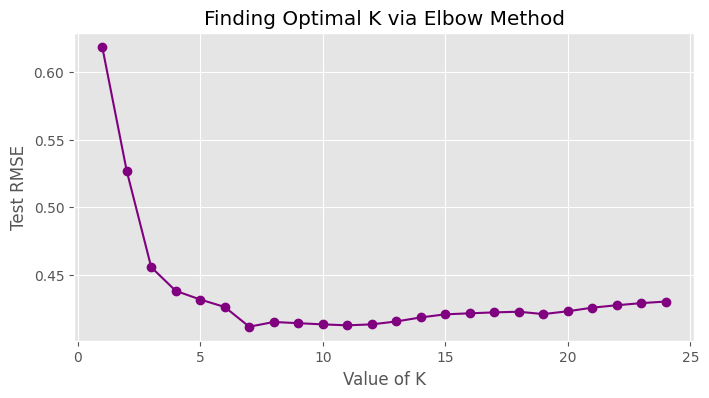

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

# Load dataset
data = fetch_california_housing()
X, y = data.data[:2000], data.target[:2000] # Subsample for speed

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Feature Scaling is critical for KNN distance calculation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

rmse_values = []
k_range = range(1, 25)

for k in k_range:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    preds = knn.predict(X_test_scaled)
    rmse_values.append(np.sqrt(mean_squared_error(y_test, preds)))

# Locate the best K
best_k = k_range[np.argmin(rmse_values)]
print(f"The optimal value is K = {best_k} with an RMSE of {min(rmse_values):.4f}")

plt.figure(figsize=(8, 4))
plt.plot(k_range, rmse_values, marker='o', color='purple')
plt.xlabel("Value of K")
plt.ylabel("Test RMSE")
plt.title("Finding Optimal K via Elbow Method")
plt.grid(True)
plt.show()

4. Extreme Values of K ($K = 1$ vs. $K = N$)

Conceptual Summary

* When $K = 1$ (Overfitting / High Variance): The model predicts the exact value of its closest neighbor. On the training set, the error will be zero. However, the decision boundary is highly sensitive to noise and outliers, leading to high test error.
* When $K = N$ (Underfitting / High Bias): The model simply averages the target values of the entire dataset. No matter what input features you provide, the model will output the exact same prediction: the statistical mean ($\mu$) of the training data.

In [16]:
import numpy as np
from sklearn.neighbors import KNeighborsRegressor

# Simple sample dataset
X_train = np.array([[1], [2], [3], [4], [5]])
y_train = np.array([10, 22, 31, 39, 50])
X_test = np.array([[2.5], [6]])

# Case A: K = 1
knn_1 = KNeighborsRegressor(n_neighbors=1)
knn_1.fit(X_train, y_train)
print(f"--- K = 1 ---")
print(f"Training predictions (Perfect fit): {knn_1.predict(X_train)}")
print(f"Test predictions (Highly volatile): {knn_1.predict(X_test)}")

# Case B: K = N (Size of entire training set, which is 5)
knn_N = KNeighborsRegressor(n_neighbors=len(X_train))
knn_N.fit(X_train, y_train)
print(f"\n--- K = N ({len(X_train)}) ---")
print(f"Dataset Mean ($\mu$): {np.mean(y_train)}")
print(f"Training predictions (Just outputs the mean): {knn_N.predict(X_train)}")
print(f"Test predictions (Just outputs the mean): {knn_N.predict(X_test)}")

--- K = 1 ---
Training predictions (Perfect fit): [10. 22. 31. 39. 50.]
Test predictions (Highly volatile): [22. 50.]

--- K = N (5) ---
Dataset Mean ($\mu$): 30.4
Training predictions (Just outputs the mean): [30.4 30.4 30.4 30.4 30.4]
Test predictions (Just outputs the mean): [30.4 30.4]


<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_24000/4135844278.py:20: SyntaxWarning: invalid escape sequence '\m'
  print(f"Dataset Mean ($\mu$): {np.mean(y_train)}")


## References ##
1. https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html
2. https://www.geeksforgeeks.org/k-nearest-neighbours/
3. https://bookdown.org/tpinto_home/Regression-and-Classification/k-nearest-neighbours-regression.html#:~:text=KNN%20regression%20is%20a%20non,observations%20in%20the%20same%20neighbourhood